# Vendor & Product Performance Analysis

## Objective
Analyze vendor sales, procurement spend, profitability, purchasing efficiency, product opportunities, and inventory exposure to identify actionable opportunities for procurement and commercial decision-making.

**Tools:** SQL, Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

### Key questions
1. Which vendors and products drive sales and procurement spend?
2. Which products combine relatively low sales with high margins and meaningful sales volume?
3. Is procurement concentrated among a small number of vendors?
4. Is larger purchasing quantity associated with lower effective unit cost?
5. Which vendors show low sales relative to purchased quantity or high estimated inventory exposure?
6. Do high-sales vendors have statistically different profit margins from low-sales vendors?

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy.stats import ttest_ind, t, mannwhitneyu, spearmanr

conn = sqlite3.connect("inventory.db")

df = pd.read_sql_query(
    "SELECT * FROM vendor_sales_summary",
    conn
)

conn.close()

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10692, 18)


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,426147.0,15305758.53,2018457.93,782997.60,68601.68,11494506.93,75.099231,2.937324,4.015940
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,480741.0,14457220.47,1684537.11,883315.98,144929.24,10653179.25,73.687603,2.930669,3.800490
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,561420.0,13614361.80,1383420.45,1031562.21,123780.22,10196058.12,74.891929,2.995726,3.982783
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,601236.0,13427918.64,1260150.03,1104728.40,257032.07,10166720.70,75.713303,2.981109,4.117480
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,407514.0,12669322.86,1637334.84,748763.49,257032.07,9646116.85,76.137588,2.950669,4.190691


## 2. Data Quality Checks

The raw dataset is retained rather than removing all loss-making observations. Negative gross profit can represent genuine loss-making business. Invalid denominators are handled only where a derived metric requires them.

In [2]:
# Data-quality summary
quality_summary = pd.DataFrame({
    "Metric": [
        "Missing values",
        "Duplicate rows",
        "Negative gross profit",
        "Zero / negative sales",
        "Zero / negative purchase quantity"
    ],
    "Count": [
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        int((df["GrossProfit"] < 0).sum()),
        int((df["TotalSalesDollars"] <= 0).sum()),
        int((df["TotalPurchaseQuantity"] <= 0).sum())
    ]
})

quality_summary["Percentage"] = (
    quality_summary["Count"] / len(df) * 100
)

display(quality_summary)

,Metric,Count,Percentage
0,Missing values,0,0.000000
1,Duplicate rows,0,0.000000
2,Negative gross profit,634,5.929667
3,Zero / negative sales,178,1.664796
4,Zero / negative purchase quantity,0,0.000000


In [3]:
# Create a clean profit-margin field without altering the raw data.
df["ProfitMargin_clean"] = pd.to_numeric(
    df["ProfitMargin"],
    errors="coerce"
).replace([np.inf, -np.inf], np.nan)

# Margin analysis only requires positive sales and a valid margin.
# Purchase quantity is not part of the profit-margin denominator.
margin_analysis_df = df[
    (df["TotalSalesDollars"] > 0) &
    df["ProfitMargin_clean"].notna()
].copy()

print(
    "Rows available for sales/profit analysis:",
    len(margin_analysis_df)
)

Rows available for sales/profit analysis: 10514


### Why this cleaning approach?

- Negative gross profit is retained because it may represent a real loss-making transaction.
- Rows with zero/negative sales are excluded only from margin-based analysis because profit margin is undefined when the denominator is zero.
- Purchase quantity is not used to validate profit margin, so records with valid sales can still contribute to product and vendor profitability analysis.
- Inventory and purchasing analyses continue to use the raw purchase/sales quantities and are handled separately.

## 3. Exploratory Data Analysis

The exploratory analysis focuses on financially meaningful KPIs and the distributions of key price, purchase-spend, and sales variables. Extreme observations are retained because they may represent genuine business conditions; visualization is adjusted where necessary to avoid letting outliers obscure the main pattern.

In [4]:
# Business-oriented KPI summary
# Sales/profit KPIs use positive-sales records; procurement KPIs use the full raw dataset.
total_sales = margin_analysis_df["TotalSalesDollars"].sum()
gross_profit = margin_analysis_df["GrossProfit"].sum()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Purchase Spend",
        "Gross Profit",
        "Overall Profit Margin",
        "Number of Vendors",
        "Number of Products"
    ],
    "Value": [
        total_sales,
        df["TotalPurchaseDollars"].sum(),
        gross_profit,
        (gross_profit / total_sales * 100) if total_sales != 0 else np.nan,
        df["VendorName"].nunique(),
        margin_analysis_df["Description"].nunique()
    ]
})

display(kpi_summary)

,KPI,Value
0,Total Sales,1.354861e+09
1,Total Purchase Spend,3.219008e+08
2,Gross Profit,1.033242e+09
3,Overall Profit Margin,7.626187e+01
4,Number of Vendors,1.280000e+02
5,Number of Products,9.483000e+03


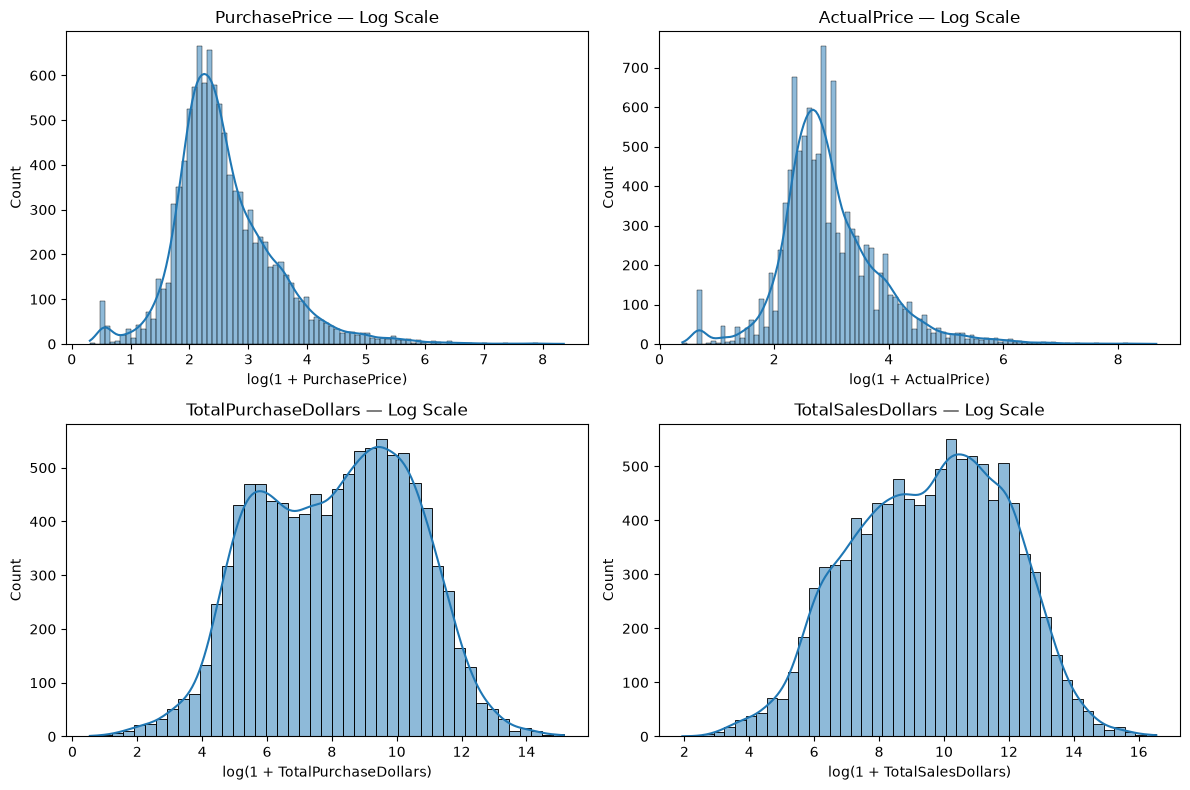

In [31]:
# Distribution of key financial metrics
# key_numeric = [
#     "PurchasePrice",
#     "ActualPrice",
#     "TotalPurchaseDollars",
#     "TotalSalesDollars"
# ]

# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# for ax, col in zip(axes.flat, key_numeric):
#     sns.histplot(
#         margin_analysis_df[col].dropna(),
#         kde=True,
#         ax=ax
#     )
#     ax.set_title(col)

# plt.tight_layout()
# plt.show()
# Distribution of key financial metrics
key_numeric = [
    "PurchasePrice",
    "ActualPrice",
    "TotalPurchaseDollars",
    "TotalSalesDollars"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, key_numeric):
    values = margin_analysis_df[col].dropna()
    values = values[values >= 0]

    sns.histplot(
        np.log1p(values),
        kde=True,
        ax=ax
    )

    ax.set_title(f"{col} — Log Scale")
    ax.set_xlabel(f"log(1 + {col})")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 4. Product Opportunity: Low Sales + High Margin

In [6]:
# Aggregate performance at product level.
# Description is the product identifier used in this dataset; this is not a brand-level aggregation.
product_performance = (
    margin_analysis_df
    .groupby("Description", as_index=False)
    .agg(
        TotalSalesDollars=("TotalSalesDollars", "sum"),
        TotalSalesQuantity=("TotalSalesQuantity", "sum"),
        GrossProfit=("GrossProfit", "sum")
    )
)

product_performance["ProfitMargin"] = (
    product_performance["GrossProfit"]
    / product_performance["TotalSalesDollars"]
    * 100
)

product_performance = product_performance[
    product_performance["TotalSalesDollars"] > 0
].copy()

display(product_performance.head())

,Description,TotalSalesDollars,TotalSalesQuantity,GrossProfit,ProfitMargin
0,(RI) 1,64557.27,1773.0,46924.67,72.686887
1,.nparalleled Svgn Blanc,3283.89,411.0,2517.41,76.659389
2,10 Span Cab Svgn CC,8111.67,1083.0,5973.91,73.645871
3,10 Span Chard CC,9976.68,1332.0,7575.84,75.935482
4,10 Span Pnt Gris Monterey Cy,6246.66,834.0,4835.46,77.408727


In [7]:
# Relative thresholds identify the low-sales / high-margin segment.
sales_threshold = product_performance["TotalSalesDollars"].quantile(0.15)
margin_threshold = product_performance["ProfitMargin"].quantile(0.85)
quantity_threshold = product_performance["TotalSalesQuantity"].quantile(0.25)

print(f"15th percentile sales threshold: ${sales_threshold:,.2f}")
print(f"85th percentile margin threshold: {margin_threshold:.2f}%")
print(f"25th percentile sales-quantity threshold: {quantity_threshold:,.0f}")

15th percentile sales threshold: $1,025.52
85th percentile margin threshold: 85.46%
25th percentile sales-quantity threshold: 105


In [28]:
# Opportunity definition:
# relatively low sales + high margin + meaningful sales volume.
product_opportunities = product_performance[
    (product_performance["TotalSalesDollars"] <= sales_threshold) &
    (product_performance["ProfitMargin"] >= margin_threshold) &
    (product_performance["TotalSalesQuantity"] >= quantity_threshold)
].copy()



product_opportunities = product_opportunities.sort_values(
    ["ProfitMargin", "TotalSalesQuantity"],
    ascending=[False, False]
)

display(product_opportunities.head(15))
print("Number of opportunity products:", len(product_opportunities))

,Description,TotalSalesDollars,TotalSalesQuantity,GrossProfit,ProfitMargin
8549,The Club Strawbry Margarita,429.84,216.0,428.37,99.658012
6057,Mojoshot Blue Lagoon RTD,950.40,960.0,940.91,99.001473
8991,Vampire Transylvania Merlot,681.45,105.0,672.91,98.746790
8548,The Club Mudslide,250.74,126.0,243.49,97.108559
9454,Zhenka Vodka 80 Proof,721.17,183.0,690.65,95.767988
7966,Skyy Infusions Georgia Peach,647.46,654.0,619.06,95.613629
7035,Proemio Chard,976.86,114.0,905.46,92.690867
6816,Philippe Herard Bl de Blanc,910.86,114.0,823.34,90.391498
246,Alta Classe Mntplcno Abruzzo,982.77,123.0,854.13,86.910467
8017,Smirnoff Sours Watermelon,436.59,441.0,373.95,85.652443


Number of opportunity products: 10


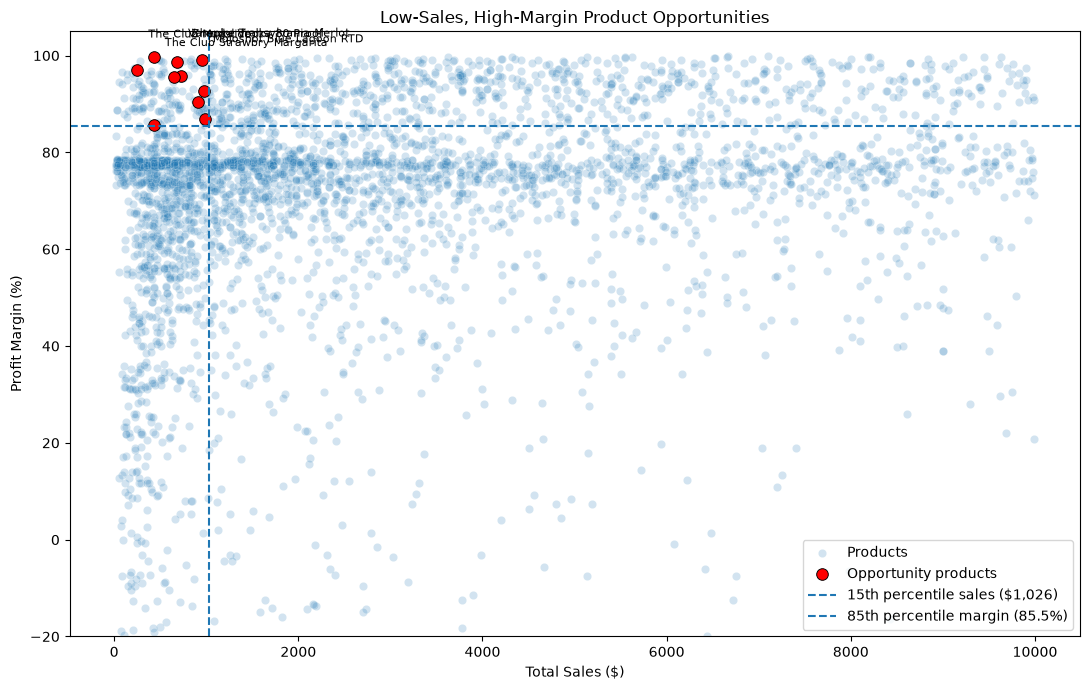

In [36]:
# # Main opportunity visualization.
# # Extreme negative margins remain in the dataset but are clipped visually to keep the
# # commercially relevant region readable.

# product_plot = product_performance[
#     product_performance["TotalSalesDollars"] < 10000
# ].copy()

# plt.figure(figsize=(11, 7))

# sns.scatterplot(
#     data=product_plot,
#     x="TotalSalesDollars",
#     y="ProfitMargin",
#     alpha=0.22,
#     s=35,
#     label="Products"
# )

# sns.scatterplot(
#     data=product_opportunities,
#     x="TotalSalesDollars",
#     y="ProfitMargin",
#     color="red",
#     s=65,
#     edgecolor="black",
#     label="Opportunity products"
# )

# # Label only the top 5 ranked opportunities.
# for i, (_, row) in enumerate(product_opportunities.head(5).iterrows()):
#     plt.annotate(
#         row["Description"],
#         (row["TotalSalesDollars"], row["ProfitMargin"]),
#         xytext=(8, 8 + i * 5),
#         textcoords="offset points",
#         fontsize=8
#     )

# plt.axvline(
#     sales_threshold,
#     linestyle="--",
#     linewidth=1.5,
#     label=f"15th percentile sales (${sales_threshold:,.0f})"
# )

# plt.axhline(
#     margin_threshold,
#     linestyle="--",
#     linewidth=1.5,
#     label=f"85th percentile margin ({margin_threshold:.1f}%)"
# )

# plt.ylim(-100, 110)
# plt.xlabel("Total Sales ($)")
# plt.ylabel("Profit Margin (%)")
# plt.title("Low-Sales, High-Margin Product Opportunities")
# plt.legend()
# plt.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=product_plot,
    x="TotalSalesDollars",
    y="ProfitMargin",
    alpha=0.20,
    s=35,
    label="Products"
)

sns.scatterplot(
    data=product_opportunities,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="red",
    s=70,
    edgecolor="black",
    label="Opportunity products"
)

for i, (_, row) in enumerate(product_opportunities.head(5).iterrows()):
    plt.annotate(
        row["Description"],
        (row["TotalSalesDollars"], row["ProfitMargin"]),
        xytext=(8, 8 + i * 5),
        textcoords="offset points",
        fontsize=8
    )

plt.axvline(
    sales_threshold,
    linestyle="--",
    label=f"15th percentile sales (${sales_threshold:,.0f})"
)

plt.axhline(
    margin_threshold,
    linestyle="--",
    label=f"85th percentile margin ({margin_threshold:.1f}%)"
)

plt.ylim(-20, 105)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Low-Sales, High-Margin Product Opportunities")

plt.legend()
plt.tight_layout()
plt.show()

### Opportunity interpretation

The red points satisfy all three screening criteria:

1. Total sales at or below the 15th percentile.
2. Profit margin at or above the 85th percentile.
3. Sales quantity at or above the 25th percentile.

These are screening candidates for commercial review, not proof that promotion will increase profit.

**Interpretation:** Opportunity products combine relatively low sales with unusually high margins and meaningful sales volume. They are candidates for further commercial review, such as distribution expansion, improved visibility, or targeted promotion. The analysis identifies candidates for investigation; it does not prove that promotion will increase profit.

## 5. Top Vendors and Products by Sales

In [10]:
top_vendors_sales = (
    df.groupby("VendorName", as_index=False)["TotalSalesDollars"]
      .sum()
      .sort_values("TotalSalesDollars", ascending=False)
      .head(10)
)

top_products_sales = (
    df.groupby("Description", as_index=False)["TotalSalesDollars"]
      .sum()
      .sort_values("TotalSalesDollars", ascending=False)
      .head(10)
)

display(top_vendors_sales)
display(top_products_sales)

,VendorName,TotalSalesDollars
28,DIAGEO NORTH AMERICA INC,2.062195e+08
63,MARTIGNETTI COMPANIES,1.228804e+08
74,PERNOD RICARD USA,9.683863e+07
50,JIM BEAM BRANDS COMPANY,9.569586e+07
8,BACARDI USA INC,7.501610e+07
23,CONSTELLATION BRANDS INC,7.340140e+07
33,E & J GALLO WINERY,5.566132e+07
14,BROWN-FORMAN CORP,5.542983e+07
114,ULTRA BEVERAGE COMPANY LLP,5.340794e+07
59,M S WALKER INC,4.630820e+07


,Description,TotalSalesDollars
4682,Jack Daniels No 7 Black,23894240.28
8900,Tito's Handmade Vodka,22198972.74
4200,Grey Goose Vodka,21628824.18
1578,Capt Morgan Spiced Rum,19068961.86
109,Absolut 80 Proof,18734256.09
4798,Jameson Irish Whiskey,17147279.07
5103,Ketel One Vodka,15210250.68
605,Baileys Irish Cream,12450366.21
5012,Kahlua,10814575.98
8567,Tanqueray,10370093.70


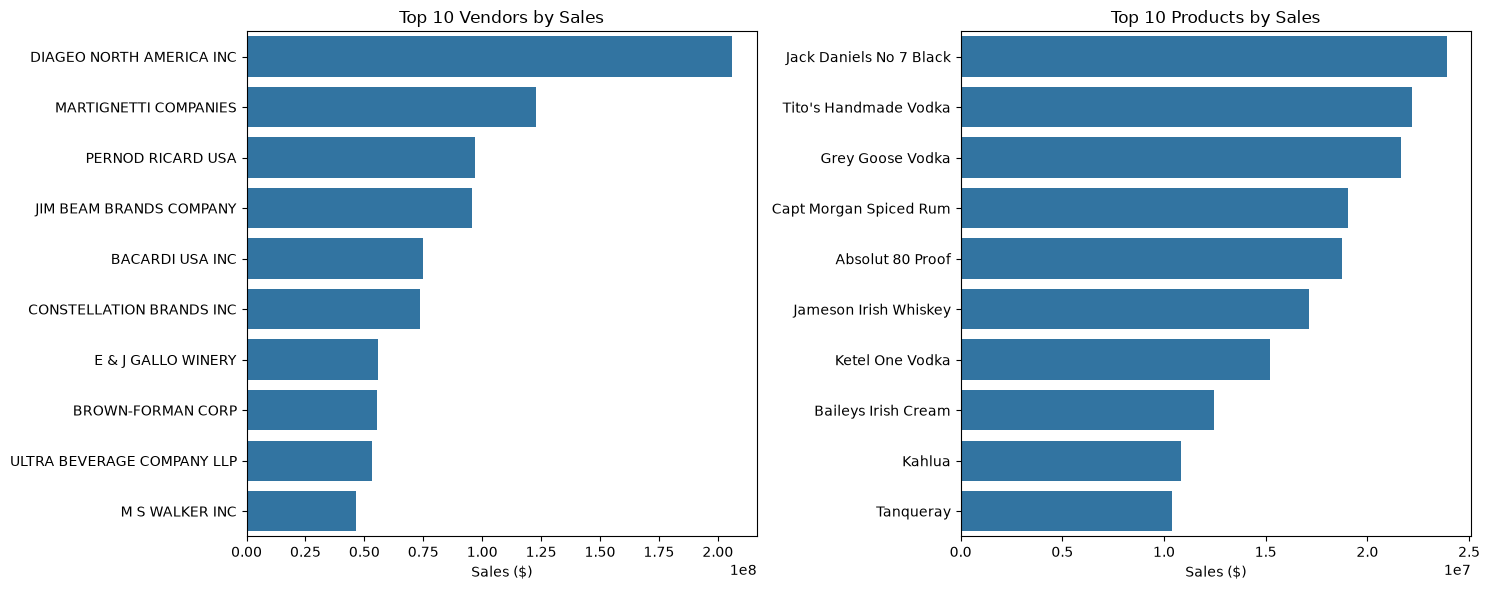

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=top_vendors_sales,
    y="VendorName",
    x="TotalSalesDollars",
    ax=axes[0]
)
axes[0].set_title("Top 10 Vendors by Sales")
axes[0].set_xlabel("Sales ($)")
axes[0].set_ylabel("")

sns.barplot(
    data=top_products_sales,
    y="Description",
    x="TotalSalesDollars",
    ax=axes[1]
)
axes[1].set_title("Top 10 Products by Sales")
axes[1].set_xlabel("Sales ($)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 6. Vendor-Level Performance and Procurement Concentration

Vendor-level aggregation is used so each vendor is represented once. Profit margin is calculated as total gross profit divided by total sales, rather than averaging row-level margins.

In [12]:
vendor_performance = (
    df.groupby("VendorName", as_index=False)
      .agg(
          TotalPurchaseDollars=("TotalPurchaseDollars", "sum"),
          TotalSalesDollars=("TotalSalesDollars", "sum"),
          GrossProfit=("GrossProfit", "sum"),
          TotalPurchaseQuantity=("TotalPurchaseQuantity", "sum"),
          TotalSalesQuantity=("TotalSalesQuantity", "sum")
      )
)

vendor_performance["ProfitMargin"] = np.where(
    vendor_performance["TotalSalesDollars"] > 0,
    vendor_performance["GrossProfit"]
    / vendor_performance["TotalSalesDollars"] * 100,
    np.nan
)

vendor_performance["PurchaseContributionPct"] = (
    vendor_performance["TotalPurchaseDollars"]
    / vendor_performance["TotalPurchaseDollars"].sum() * 100
)

vendor_performance["SalesContributionPct"] = (
    vendor_performance["TotalSalesDollars"]
    / vendor_performance["TotalSalesDollars"].sum() * 100
)

vendor_performance["GrossProfitContributionPct"] = np.where(
    vendor_performance["GrossProfit"].sum() != 0,
    vendor_performance["GrossProfit"]
    / vendor_performance["GrossProfit"].sum() * 100,
    np.nan
)

# Keep separate rankings so a purchase-spend ranking is not accidentally used as a sales ranking.
vendor_performance_by_purchase = vendor_performance.sort_values(
    "PurchaseContributionPct", ascending=False
).copy()

vendor_performance_by_sales = vendor_performance.sort_values(
    "SalesContributionPct", ascending=False
).copy()

display(vendor_performance_by_purchase.head(10))

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,TotalPurchaseQuantity,TotalSalesQuantity,ProfitMargin,PurchaseContributionPct,SalesContributionPct,GrossProfitContributionPct
28,DIAGEO NORTH AMERICA INC,50959796.85,2.062195e+08,1.552597e+08,5459788,16267005.0,75.288566,15.830903,15.220718,15.030567
63,MARTIGNETTI COMPANIES,27861690.02,1.228804e+08,9.501866e+07,2640411,7735788.0,77.326164,8.655366,9.069594,9.198680
50,JIM BEAM BRANDS COMPANY,24203151.05,9.569586e+07,7.149271e+07,2737165,7889892.0,74.708258,7.518824,7.063152,6.921152
74,PERNOD RICARD USA,24124091.56,9.683863e+07,7.271454e+07,1647558,4840014.0,75.088360,7.494263,7.147498,7.039436
8,BACARDI USA INC,17624378.72,7.501610e+07,5.739172e+07,1427075,4371033.0,76.505871,5.475097,5.536813,5.556046
23,CONSTELLATION BRANDS INC,15573917.90,7.340140e+07,5.782748e+07,2325892,6904374.0,78.782534,4.838111,5.417635,5.598232
14,BROWN-FORMAN CORP,13529433.08,5.542983e+07,4.190040e+07,1006122,2951220.0,75.591785,4.202983,4.091184,4.056344
114,ULTRA BEVERAGE COMPANY LLP,13210613.93,5.340794e+07,4.019732e+07,1077527,3126810.0,75.264700,4.103940,3.941951,3.891470
33,E & J GALLO WINERY,12289608.09,5.566132e+07,4.337172e+07,1858260,5426154.0,77.920741,3.817825,4.108270,4.198781
59,M S WALKER INC,10935817.30,4.630820e+07,3.537238e+07,1372841,4026690.0,76.384706,3.397264,3.417931,3.424372


In [13]:
top10_purchase_share = vendor_performance_by_purchase.head(10)[
    "PurchaseContributionPct"
].sum()

top10_sales_share = vendor_performance_by_sales.head(10)[
    "SalesContributionPct"
].sum()

print(
    f"Top 10 vendors account for {top10_purchase_share:.2f}% "
    "of total purchase spend."
)
print(
    f"Top 10 vendors account for {top10_sales_share:.2f}% "
    "of total sales."
)

Top 10 vendors account for 65.33% of total purchase spend.
Top 10 vendors account for 65.01% of total sales.


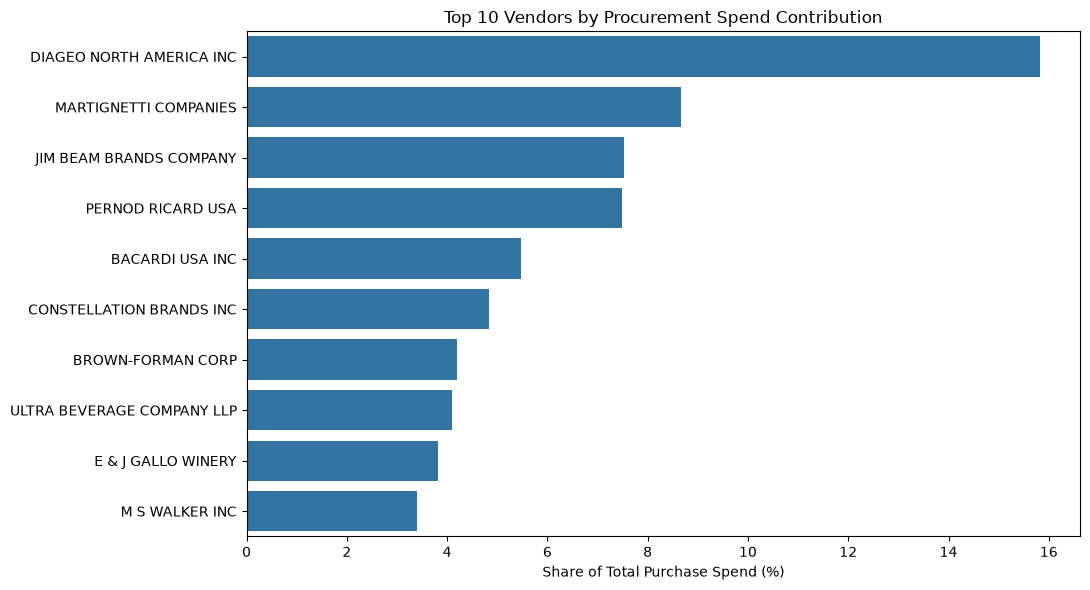

In [14]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=vendor_performance_by_purchase.head(10),
    x="PurchaseContributionPct",
    y="VendorName"
)
plt.xlabel("Share of Total Purchase Spend (%)")
plt.ylabel("")
plt.title("Top 10 Vendors by Procurement Spend Contribution")
plt.tight_layout()
plt.show()

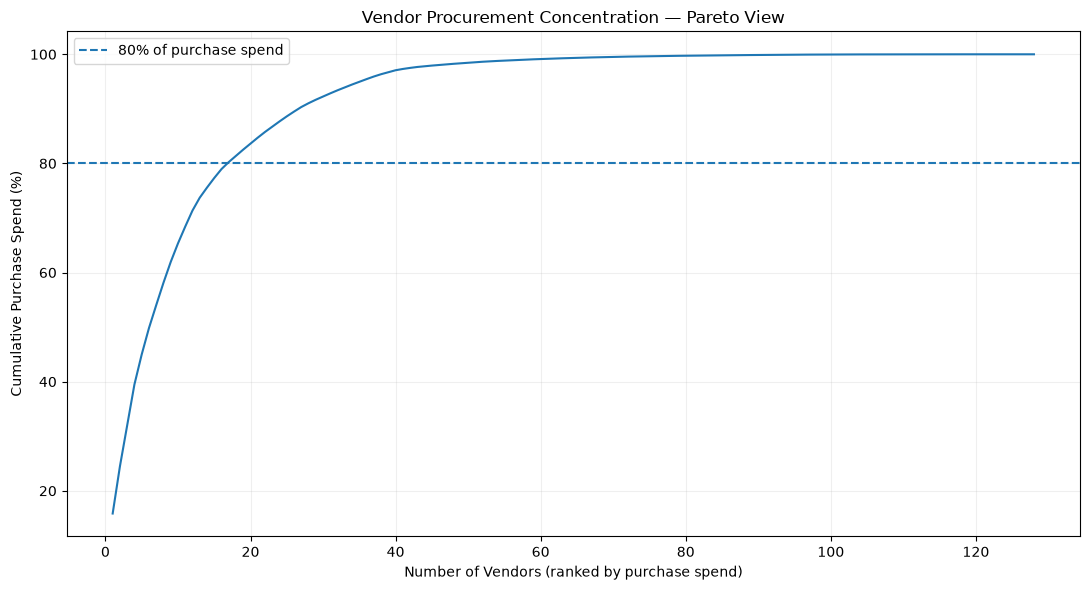

In [15]:
# Pareto view of procurement concentration
vendor_pareto = vendor_performance.sort_values(
    "TotalPurchaseDollars",
    ascending=False
).copy()

vendor_pareto["CumulativePurchasePct"] = (
    vendor_pareto["PurchaseContributionPct"].cumsum()
)

plt.figure(figsize=(11, 6))

plt.plot(
    range(1, len(vendor_pareto) + 1),
    vendor_pareto["CumulativePurchasePct"]
)

plt.axhline(80, linestyle="--", label="80% of purchase spend")

plt.xlabel("Number of Vendors (ranked by purchase spend)")
plt.ylabel("Cumulative Purchase Spend (%)")
plt.title("Vendor Procurement Concentration — Pareto View")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Key insight:** Procurement concentration should be evaluated alongside sales concentration. A high top-10 procurement share indicates supplier dependency and potential negotiation leverage, while a high top-10 sales share indicates revenue concentration. Both metrics are useful for vendor strategy and continuity planning.

The comparison should be interpreted as concentration, not as evidence that vendors cause the observed sales or profit outcomes.

## 7. Bulk Purchasing and Unit Purchase Price

In [16]:
bulk_df = df[df["TotalPurchaseQuantity"] > 0].copy()

bulk_df["UnitPurchasePrice"] = (
    bulk_df["TotalPurchaseDollars"]
    / bulk_df["TotalPurchaseQuantity"]
)

# Terciles describe relative purchase-quantity bands in this dataset;
# they are not universal optimal order-size thresholds.
bulk_df["PurchaseQuantityBand"] = pd.qcut(
    bulk_df["TotalPurchaseQuantity"],
    q=3,
    labels=["Small", "Medium", "Large"],
    duplicates="drop"
)

bulk_summary = (
    bulk_df.groupby("PurchaseQuantityBand", observed=True)
    .agg(
        PurchaseQuantity=("TotalPurchaseQuantity", "sum"),
        PurchaseDollars=("TotalPurchaseDollars", "sum")
    )
    .reset_index()
)

bulk_summary["WeightedUnitPurchasePrice"] = (
    bulk_summary["PurchaseDollars"]
    / bulk_summary["PurchaseQuantity"]
)

display(bulk_summary)

,PurchaseQuantityBand,PurchaseQuantity,PurchaseDollars,WeightedUnitPurchasePrice
0,Small,82610,2.272159e+06,27.504654
1,Medium,1272094,2.155138e+07,16.941656
2,Large,32227658,2.980772e+08,9.249112


In [17]:
# Robust association check between purchase quantity and effective unit purchase price.
bulk_corr_df = bulk_df[
    (bulk_df["TotalPurchaseQuantity"] > 0) &
    (bulk_df["UnitPurchasePrice"].notna())
].copy()

spearman_rho, spearman_p = spearmanr(
    bulk_corr_df["TotalPurchaseQuantity"],
    bulk_corr_df["UnitPurchasePrice"]
)

print(f"Spearman correlation (quantity vs unit purchase price): {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.6g}")

Spearman correlation (quantity vs unit purchase price): -0.275
Spearman p-value: 3.81607e-184


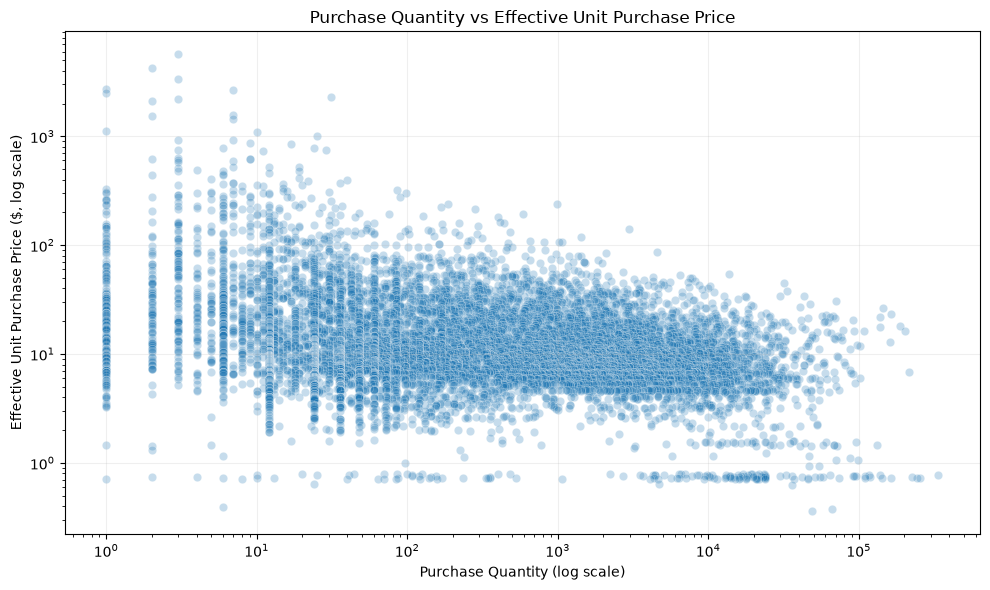

In [37]:
# plt.figure(figsize=(9, 5))
# sns.boxplot(
#     data=bulk_df,
#     x="PurchaseQuantityBand",
#     y="UnitPurchasePrice"
# )

# for i, row in bulk_summary.iterrows():
#     plt.text(
#         i,
#         row["WeightedUnitPurchasePrice"],
#         f"${row['WeightedUnitPurchasePrice']:.2f}",
#         ha="center",
#         va="bottom"
#     )

# plt.xlabel("Purchase Quantity Band")
# plt.ylabel("Unit Purchase Price ($)")
# plt.title("Unit Purchase Price Across Purchase-Quantity Bands")
# plt.tight_layout()
# plt.show()
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=bulk_corr_df,
    x="TotalPurchaseQuantity",
    y="UnitPurchasePrice",
    alpha=0.25
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Purchase Quantity (log scale)")
plt.ylabel("Effective Unit Purchase Price ($, log scale)")
plt.title("Purchase Quantity vs Effective Unit Purchase Price")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Key insight:** The weighted effective unit purchase price can be compared across the relative purchase-quantity bands. A lower unit cost in larger-quantity bands would indicate an association between purchase quantity and lower effective cost. Because the bands are data-driven terciles, this does not establish a universal optimal order size or causality.

## 8. Sales-to-Purchase Ratio

In [19]:
# A transparent quantity-based measure: sales quantity relative to purchased quantity.
# This is intentionally labelled as a ratio rather than the accounting definition of inventory turnover.
vendor_performance["SalesToPurchaseRatio"] = np.where(
    vendor_performance["TotalPurchaseQuantity"] > 0,
    vendor_performance["TotalSalesQuantity"]
    / vendor_performance["TotalPurchaseQuantity"],
    np.nan
)

low_sales_purchase_vendors = (
    vendor_performance[
        vendor_performance["SalesToPurchaseRatio"] < 1
    ]
    .sort_values("SalesToPurchaseRatio")
    [[
        "VendorName",
        "SalesToPurchaseRatio",
        "TotalPurchaseQuantity",
        "TotalSalesQuantity"
    ]]
    .head(10)
)

display(low_sales_purchase_vendors)

,VendorName,SalesToPurchaseRatio,TotalPurchaseQuantity,TotalSalesQuantity
0,AAPER ALCOHOL & CHEMICAL CO,0.000000,1,0.0
56,LAUREATE IMPORTS CO,0.000000,29,0.0
112,TRUETT HURST,0.125000,24,3.0
48,"IRA GOLDMAN AND WILLIAMS, LLP",0.384146,328,126.0
45,HIGHLAND WINE MERCHANTS LLC,0.661290,372,246.0
115,UNCORKED,0.753086,243,183.0
119,VINEYARD BRANDS LLC,0.840970,371,312.0
57,LOYAL DOG WINERY,0.925000,240,222.0


**Interpretation:** A sales-to-purchase ratio below 1 means cumulative sales quantity is lower than cumulative purchase quantity in the summarized data. This can indicate slower movement or potential inventory accumulation, but it is not proof of excess stock because opening inventory, timing, returns, and stock transfers are not available.

## 9. Estimated Inventory Exposure

In [20]:
inventory_df = df.copy()

inventory_df["UnsoldQuantity"] = (
    inventory_df["TotalPurchaseQuantity"]
    - inventory_df["TotalSalesQuantity"]
).clip(lower=0)

# Screening metric only: purchase price is used as a proxy for inventory cost.
inventory_df["EstimatedInventoryExposure"] = (
    inventory_df["UnsoldQuantity"]
    * inventory_df["PurchasePrice"]
)

unsold_by_vendor = (
    inventory_df.groupby("VendorName", as_index=False)
    .agg(
        UnsoldQuantity=("UnsoldQuantity", "sum"),
        EstimatedInventoryExposure=("EstimatedInventoryExposure", "sum"),
        TotalPurchaseDollars=("TotalPurchaseDollars", "sum")
    )
    .sort_values("EstimatedInventoryExposure", ascending=False)
)

unsold_by_vendor["ShareOfEstimatedExposurePct"] = (
    unsold_by_vendor["EstimatedInventoryExposure"]
    / unsold_by_vendor["EstimatedInventoryExposure"].sum() * 100
)

display(unsold_by_vendor.head(10))

,VendorName,UnsoldQuantity,EstimatedInventoryExposure,TotalPurchaseDollars,ShareOfEstimatedExposurePct
114,ULTRA BEVERAGE COMPANY LLP,9565.0,302196.51,13210613.93,21.423572
63,MARTIGNETTI COMPANIES,13037.0,252573.69,27861690.02,17.905669
59,M S WALKER INC,17462.0,229873.46,10935817.30,16.296385
73,PERFECTA WINES,7307.0,188642.83,5665501.53,13.373428
94,SOUTHERN WINE & SPIRITS NE,1121.0,40002.75,3699813.46,2.835909
50,JIM BEAM BRANDS COMPANY,127.0,38953.91,24203151.05,2.761554
76,PINE STATE TRADING CO,1725.0,35632.45,3129071.59,2.526086
28,DIAGEO NORTH AMERICA INC,307.0,31196.10,50959796.85,2.211580
100,"STOLI GROUP,(USA) LLC",2526.0,24027.03,3666478.72,1.703345
58,LUXCO INC,727.0,19514.64,2051436.01,1.383448


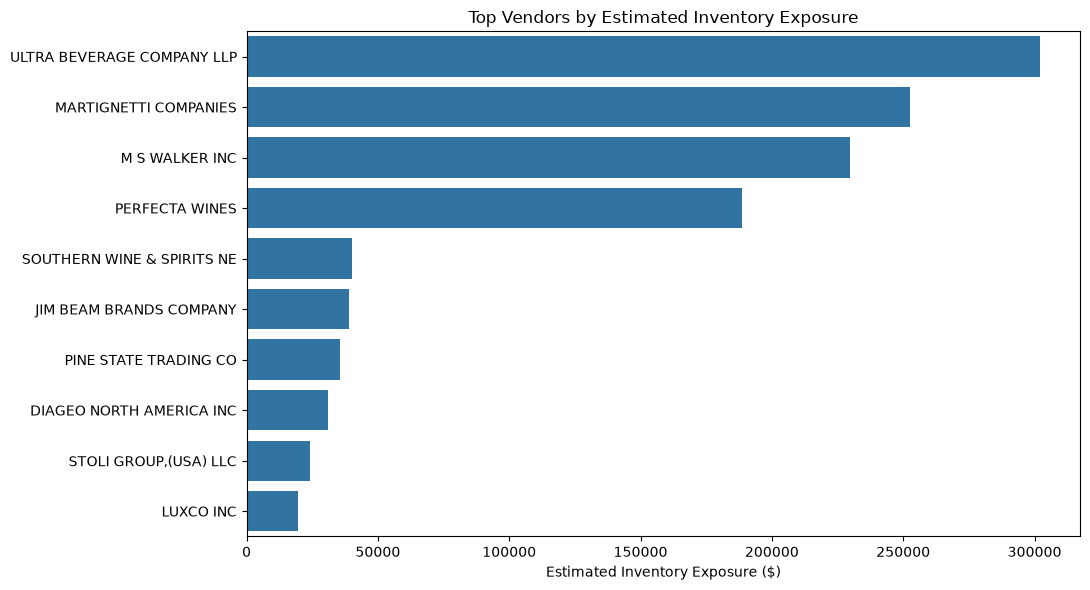

In [21]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=unsold_by_vendor.head(10),
    x="EstimatedInventoryExposure",
    y="VendorName"
)
plt.xlabel("Estimated Inventory Exposure ($)")
plt.ylabel("")
plt.title("Top Vendors by Estimated Inventory Exposure")
plt.tight_layout()
plt.show()

**Important definition:** Estimated inventory exposure is calculated as `(purchase quantity − sales quantity, floored at zero) × purchase price`. It is a screening metric, not an accounting inventory valuation. It should be validated against actual opening/closing inventory and transaction timing before being used for financial reporting.

## 10. Are High-Sales Vendors More Profitable?

This test is performed at the **vendor level**, not at the product/vendor-row level. That avoids treating multiple products from the same vendor as independent vendors.

In [22]:
vendor_test_df = vendor_performance.dropna(
    subset=["ProfitMargin", "TotalSalesDollars"]
).copy()

top_sales_threshold = vendor_test_df["TotalSalesDollars"].quantile(0.75)
low_sales_threshold = vendor_test_df["TotalSalesDollars"].quantile(0.25)

high_sales_vendors = vendor_test_df.loc[
    vendor_test_df["TotalSalesDollars"] >= top_sales_threshold,
    "ProfitMargin"
]

low_sales_vendors = vendor_test_df.loc[
    vendor_test_df["TotalSalesDollars"] <= low_sales_threshold,
    "ProfitMargin"
]

print("High-sales vendors:", len(high_sales_vendors))
print("Low-sales vendors:", len(low_sales_vendors))
print("High-sales mean margin:", round(high_sales_vendors.mean(), 2), "%")
print("Low-sales mean margin:", round(low_sales_vendors.mean(), 2), "%")

High-sales vendors: 32
Low-sales vendors: 32
High-sales mean margin: 76.62 %
Low-sales mean margin: 47.36 %


In [23]:
def mean_ci(data, confidence=0.95):
    data = np.asarray(data, dtype=float)
    mean = data.mean()
    se = data.std(ddof=1) / np.sqrt(len(data))
    critical = t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin = critical * se
    return mean, mean - margin, mean + margin

high_mean, high_lower, high_upper = mean_ci(high_sales_vendors)
low_mean, low_lower, low_upper = mean_ci(low_sales_vendors)

t_stat, p_value = ttest_ind(
    high_sales_vendors,
    low_sales_vendors,
    equal_var=False
)

print(f"High-sales vendors 95% CI: ({high_lower:.2f}%, {high_upper:.2f}%)")
print(f"Low-sales vendors 95% CI: ({low_lower:.2f}%, {low_upper:.2f}%)")
print(f"Welch t-statistic: {t_stat:.4f}")
print(f"Welch p-value: {p_value:.6g}")

High-sales vendors 95% CI: (76.01%, 77.23%)
Low-sales vendors 95% CI: (13.92%, 80.80%)
Welch t-statistic: 1.7842
Welch p-value: 0.0841711


### Statistical interpretation

**H₀:** Mean profit margins are equal between high-sales and low-sales vendors.

**H₁:** Mean profit margins differ between the two groups.

Welch's t-test is used because the two groups may have different variances and sample sizes. If the p-value is below 0.05, reject H₀ and conclude that the groups have statistically different mean profit margins.

Because the underlying product-level margins contain substantial outliers, statistical significance should be considered alongside effect size and a non-parametric robustness check.

In [24]:
# Practical effect size: Cohen's d

def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(
        (
            (nx - 1) * x.var(ddof=1)
            + (ny - 1) * y.var(ddof=1)
        ) / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_sd

margin_gap = high_sales_vendors.mean() - low_sales_vendors.mean()
effect_size = cohens_d(high_sales_vendors, low_sales_vendors)

u_stat, u_pvalue = mannwhitneyu(
    high_sales_vendors,
    low_sales_vendors,
    alternative="two-sided"
)

print(f"Difference in mean profit margin: {margin_gap:.2f} percentage points")
print(f"Cohen's d: {effect_size:.3f}")
print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"Mann-Whitney p-value: {u_pvalue:.6g}")

Difference in mean profit margin: 29.26 percentage points
Cohen's d: 0.446
Mann-Whitney U statistic: 654.00
Mann-Whitney p-value: 0.0574407


In [25]:
# Compact statistical summary for reporting
statistical_summary = pd.DataFrame({
    "Metric": [
        "High-sales mean margin",
        "Low-sales mean margin",
        "Mean margin difference",
        "Welch p-value",
        "Cohen's d",
        "Mann-Whitney p-value"
    ],
    "Value": [
        high_sales_vendors.mean(),
        low_sales_vendors.mean(),
        margin_gap,
        p_value,
        effect_size,
        u_pvalue
    ]
})

display(statistical_summary)

,Metric,Value
0,High-sales mean margin,76.621141
1,Low-sales mean margin,47.359417
2,Mean margin difference,29.261723
3,Welch p-value,0.084171
4,Cohen's d,0.446058
5,Mann-Whitney p-value,0.057441


## 11. Key Business Insights

1. **Procurement concentration:** Compare the top-10 vendor share of purchase spend with the top-10 vendor share of sales to assess supplier dependency and revenue concentration.
2. **Product opportunity:** A subset of products combines relatively low sales with high margins and meaningful sales volume, making them candidates for targeted commercial review.
3. **Purchasing efficiency:** Larger purchase-quantity bands can be compared with weighted effective unit purchase price to identify potential volume-discount patterns.
4. **Inventory exposure:** Vendors with low sales-to-purchase ratios and high estimated inventory exposure warrant further inventory review.
5. **Vendor profitability:** High-sales and low-sales vendors can be compared using confidence intervals, Welch's t-test, Cohen's d, and a Mann–Whitney robustness check.
6. **Decision focus:** The analysis is intended to prioritize vendors/products for investigation rather than claim causality from observational data.

## 12. Business Recommendations

### 1. Prioritize strategic vendor management
Focus negotiation, continuity planning, and supplier-risk monitoring on vendors contributing the largest share of procurement spend and/or sales.

### 2. Review high-exposure vendors
Prioritize vendors with high estimated inventory exposure and low sales-to-purchase ratios for a detailed stock and replenishment review.

### 3. Investigate high-margin, low-sales products
Prioritize products with high margins, relatively low sales, and meaningful sales volume for targeted distribution, visibility, and promotion experiments rather than blanket discounting.

### 4. Evaluate bulk-purchasing economics
Investigate whether the lower effective unit costs observed in larger purchase-quantity bands are driven by negotiated discounts, product mix, or other purchasing factors.

### 5. Validate before operational action
Use transaction-level dates, opening/closing inventory, returns, discounts, and actual purchase terms to validate the screening metrics before changing supplier or inventory policy.

## 13. Limitations & Next Steps

- The dataset is summarized at product/vendor level, so some metrics depend on the aggregation logic used to build `vendor_sales_summary`.
- Estimated inventory exposure uses purchase price as a proxy for inventory cost and should be validated against actual inventory valuation.
- The sales-to-purchase ratio is a quantity-based screening ratio, not an accounting inventory-turnover measure.
- Purchase-quantity terciles are relative to this dataset and should not be interpreted as universal optimal order sizes.
- The high-sales vs low-sales statistical comparison shows association, not causation.
- Profit-margin outliers can be extreme when sales are very small; this is why effect size and a non-parametric robustness check are included.
- Future analysis should incorporate transaction dates, opening/closing inventory, returns, discounts, lead times, and supplier terms to support stronger causal and operational conclusions.

## 14. Export for Power BI

In [26]:
# Export the row-level dataset with derived fields for Power BI.
powerbi_df = df.copy()

powerbi_df["UnitPurchasePrice"] = np.where(
    powerbi_df["TotalPurchaseQuantity"] > 0,
    powerbi_df["TotalPurchaseDollars"]
    / powerbi_df["TotalPurchaseQuantity"],
    np.nan
)

powerbi_df["UnsoldQuantity"] = (
    powerbi_df["TotalPurchaseQuantity"]
    - powerbi_df["TotalSalesQuantity"]
).clip(lower=0)

powerbi_df["EstimatedInventoryExposure"] = (
    powerbi_df["UnsoldQuantity"]
    * powerbi_df["PurchasePrice"]
)

powerbi_df.to_csv(
    "vendor_analysis_powerbi.csv",
    index=False
)

print("Exported:", powerbi_df.shape, "rows/columns")

Exported: (10692, 22) rows/columns


## Final Takeaway

The analysis identifies procurement and sales concentration, potential volume-related purchasing efficiencies, products that warrant commercial review, and vendors with potential inventory exposure. The strongest decisions should combine **sales, profitability, procurement spend, purchase quantity, and inventory context** rather than relying on any single metric.